
Loading and preprocessing Bogura NASA POWER dataset...

Dataset partitions:
Train:      1992-01-01 to 2023-12-01 | samples=384
Validation: 2024-01-01 to 2024-12-01 | samples=12
Test:       2025-01-01 to 2025-12-01 | samples=12

Training baseline averages from 1990-2023:
Historical Average Monthly Rainfall: 128.3277
Historical Average Monthly Solar Radiation: 16.5234

Running Bi-LSTM hyperparameter diagnostics...

Finished Bi-LSTM diagnostic: lr=0.01, batch=16, best_val_huber=0.005509, mean_NRMSE=0.1036
Finished Bi-LSTM diagnostic: lr=0.01, batch=32, best_val_huber=0.006248, mean_NRMSE=0.1117
Finished Bi-LSTM diagnostic: lr=0.01, batch=64, best_val_huber=0.007606, mean_NRMSE=0.1233
Finished Bi-LSTM diagnostic: lr=0.003, batch=16, best_val_huber=0.004925, mean_NRMSE=0.0992
Finished Bi-LSTM diagnostic: lr=0.003, batch=32, best_val_huber=0.019074, mean_NRMSE=0.1950
Finished Bi-LSTM diagnostic: lr=0.003, batch=64, best_val_huber=0.016492, mean_NRMSE=0.1815
Finished Bi-LSTM diagnostic: lr=0

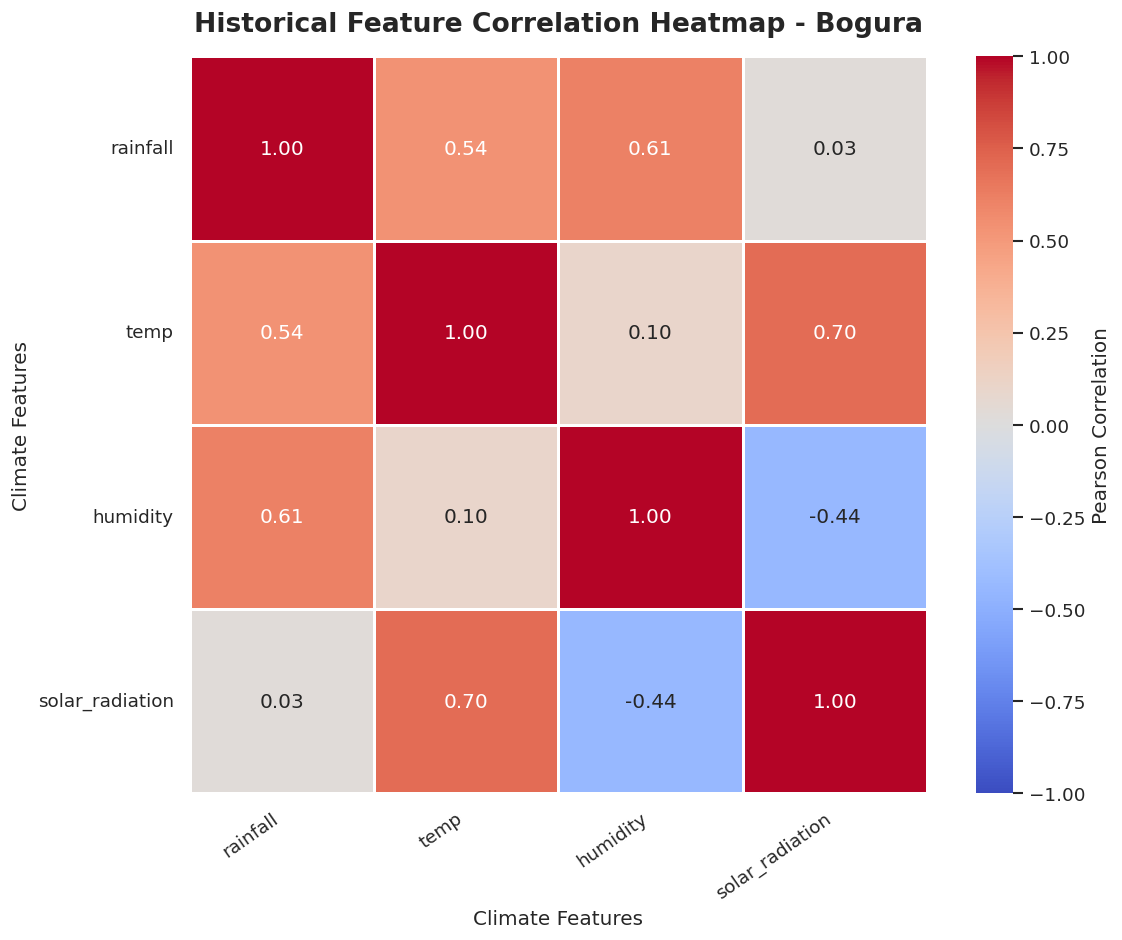

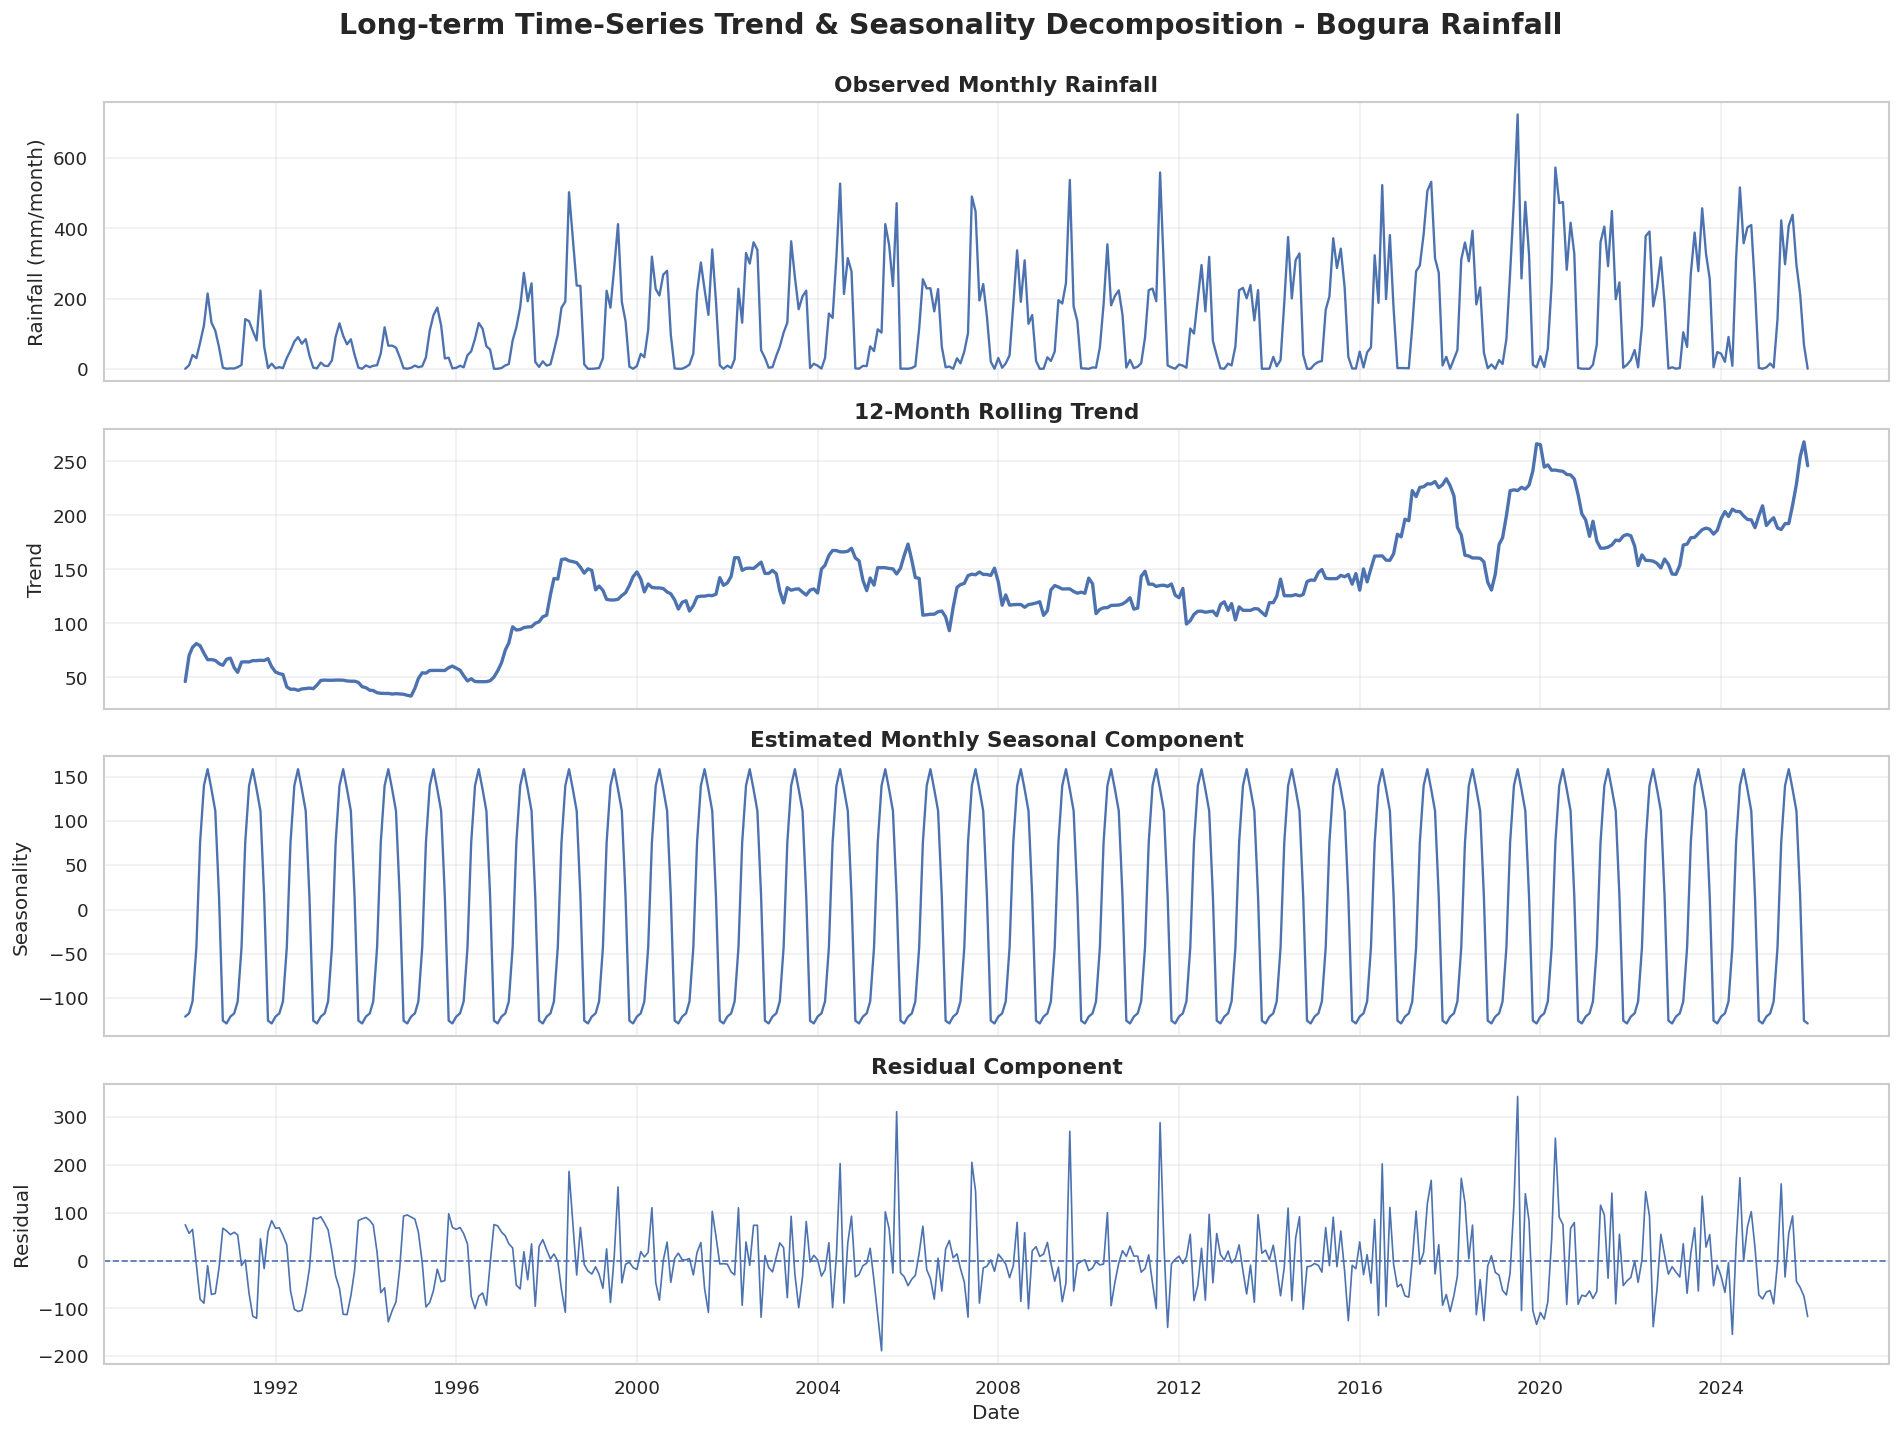

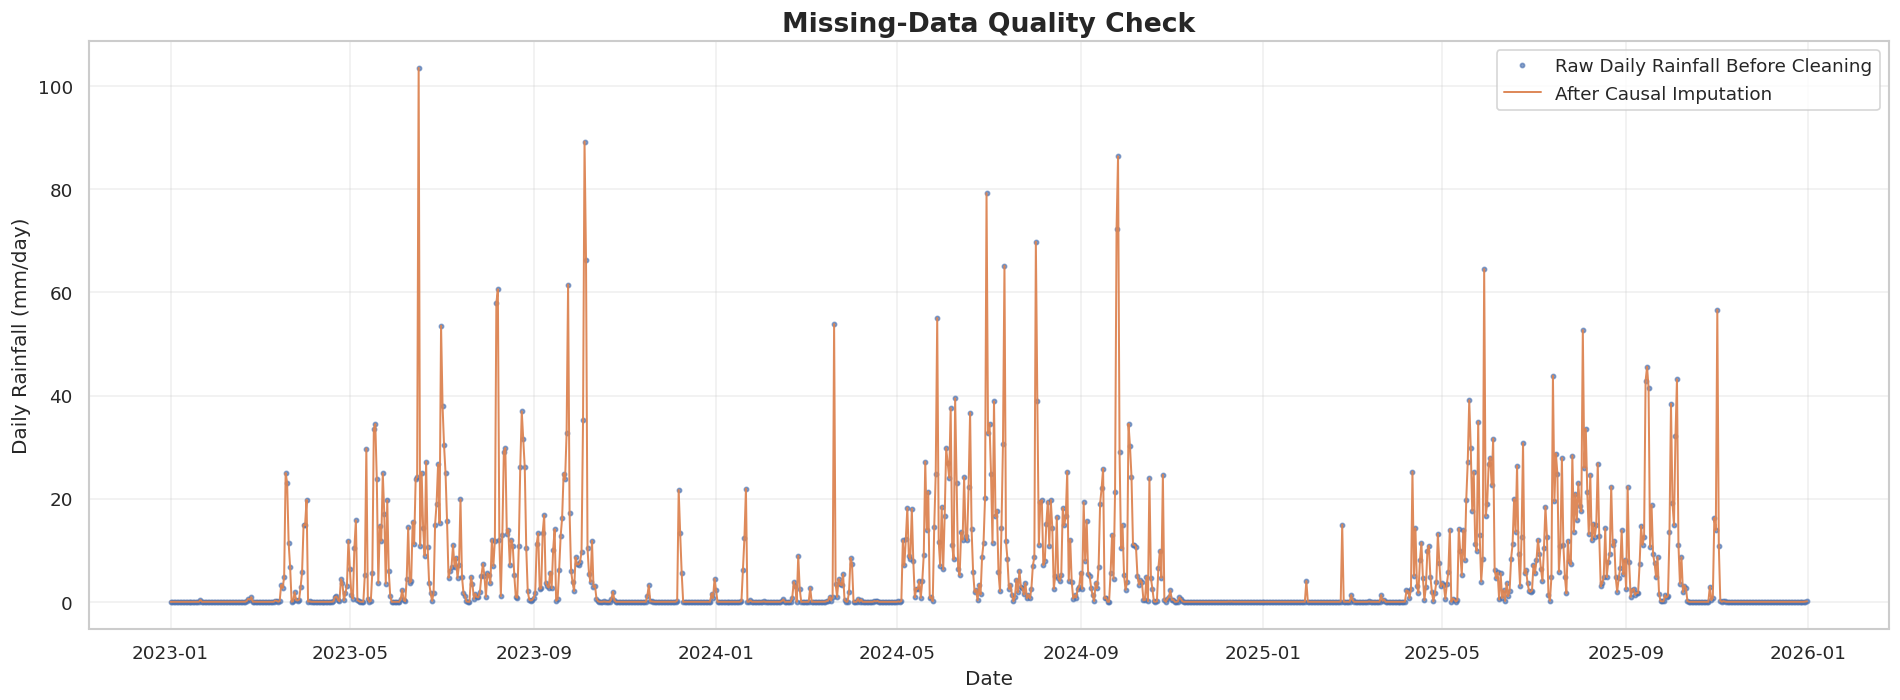

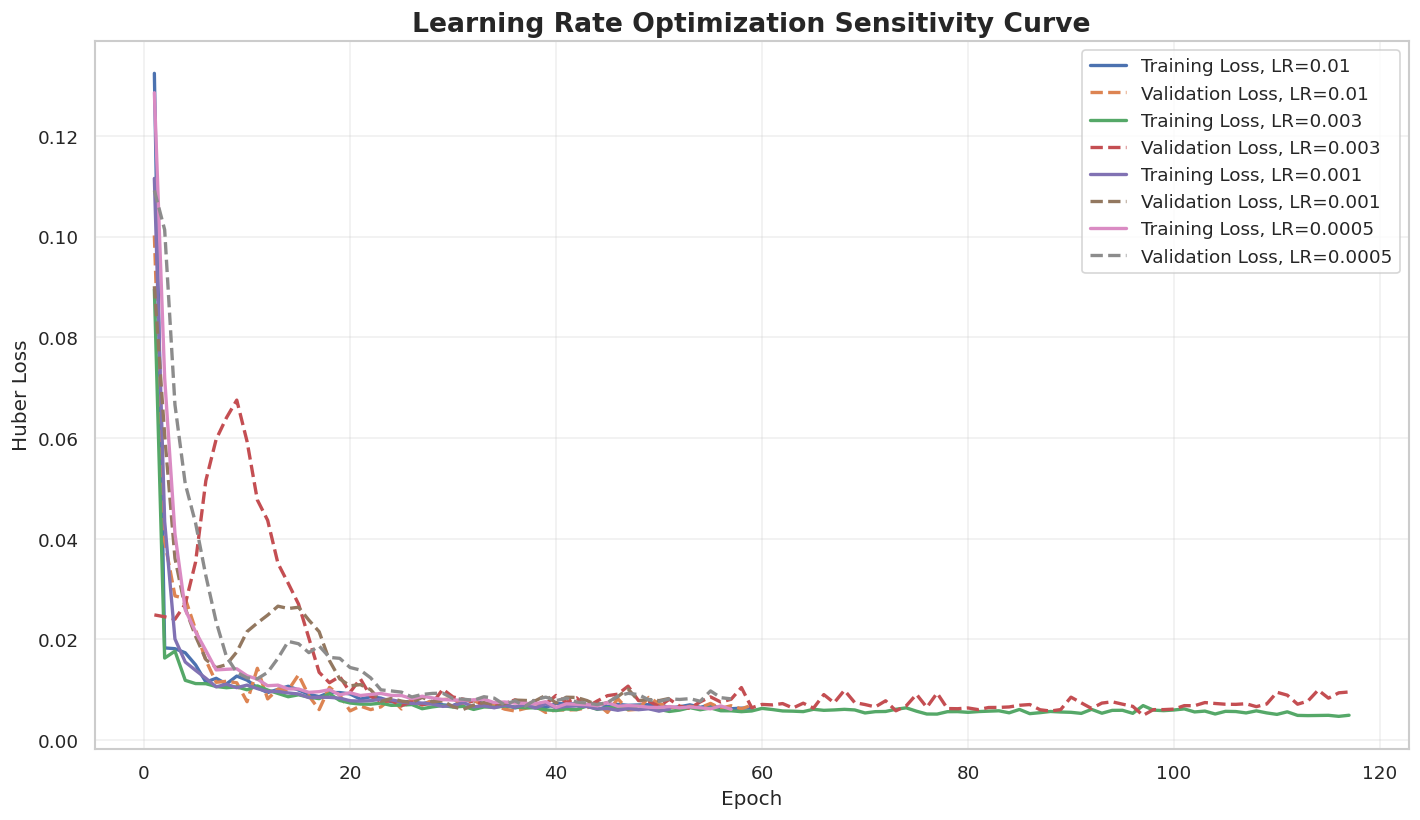

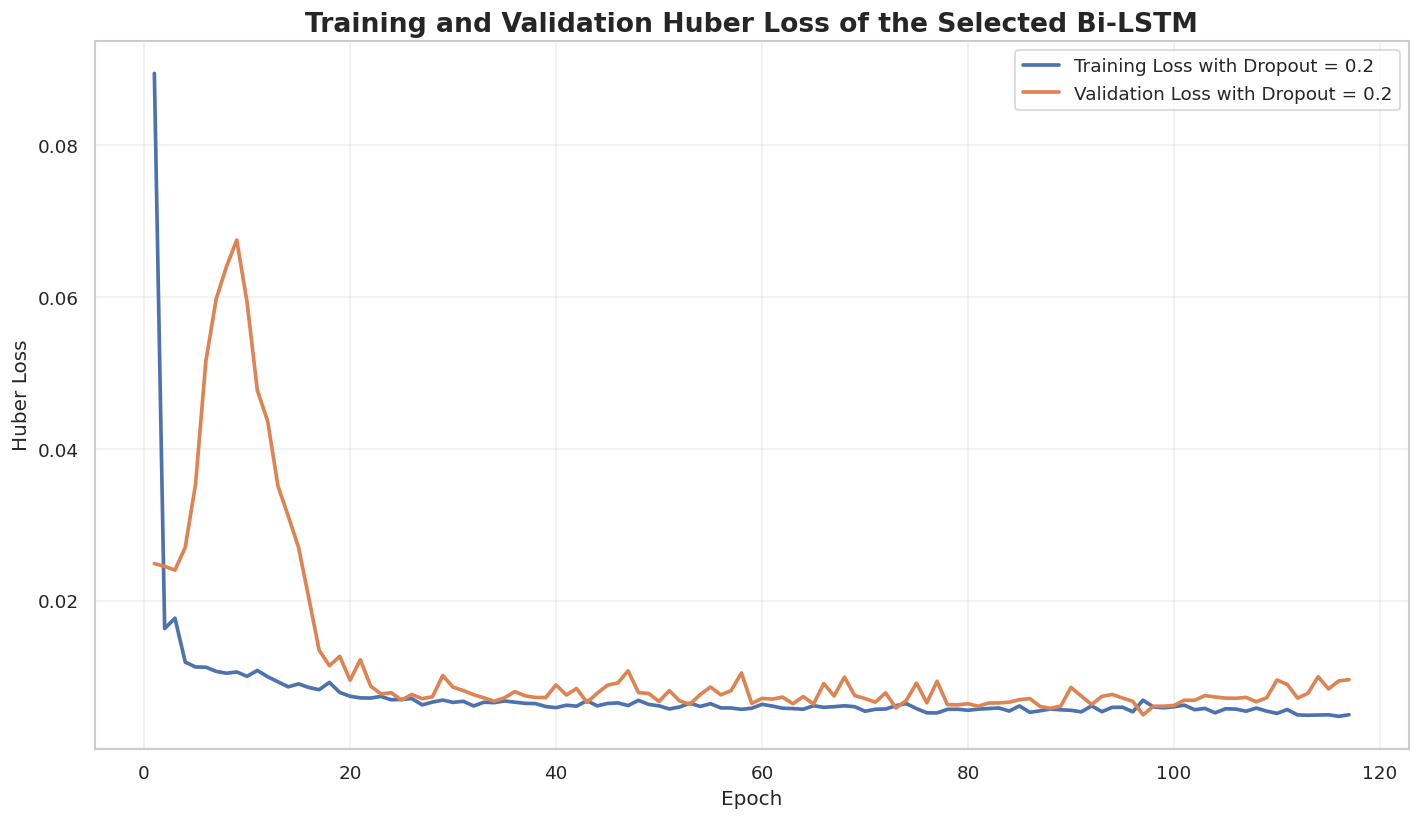

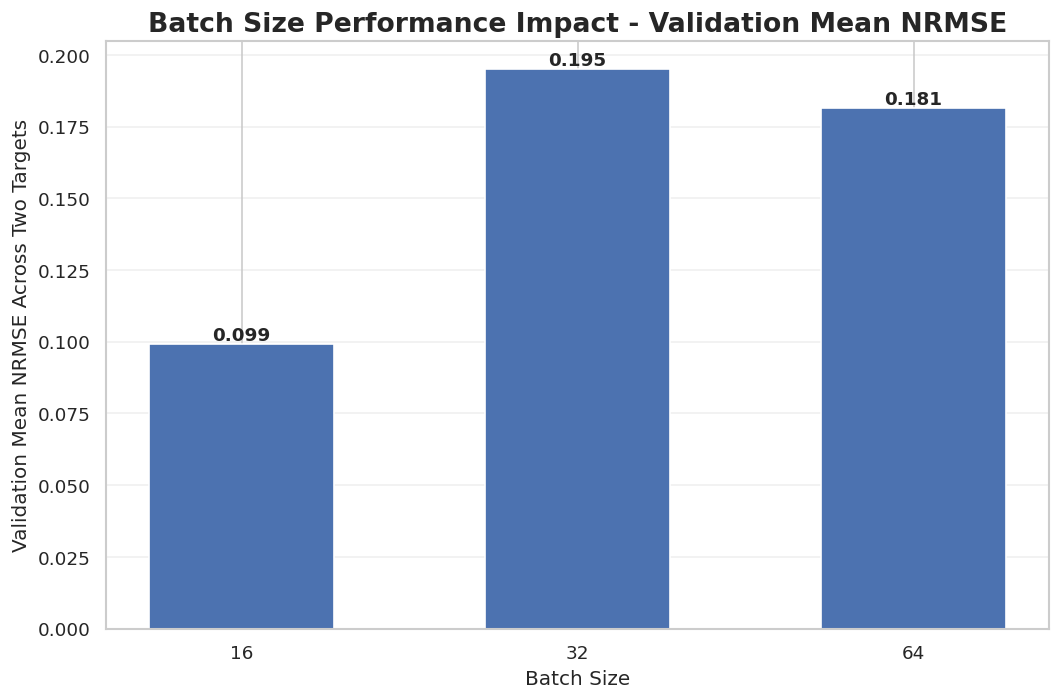

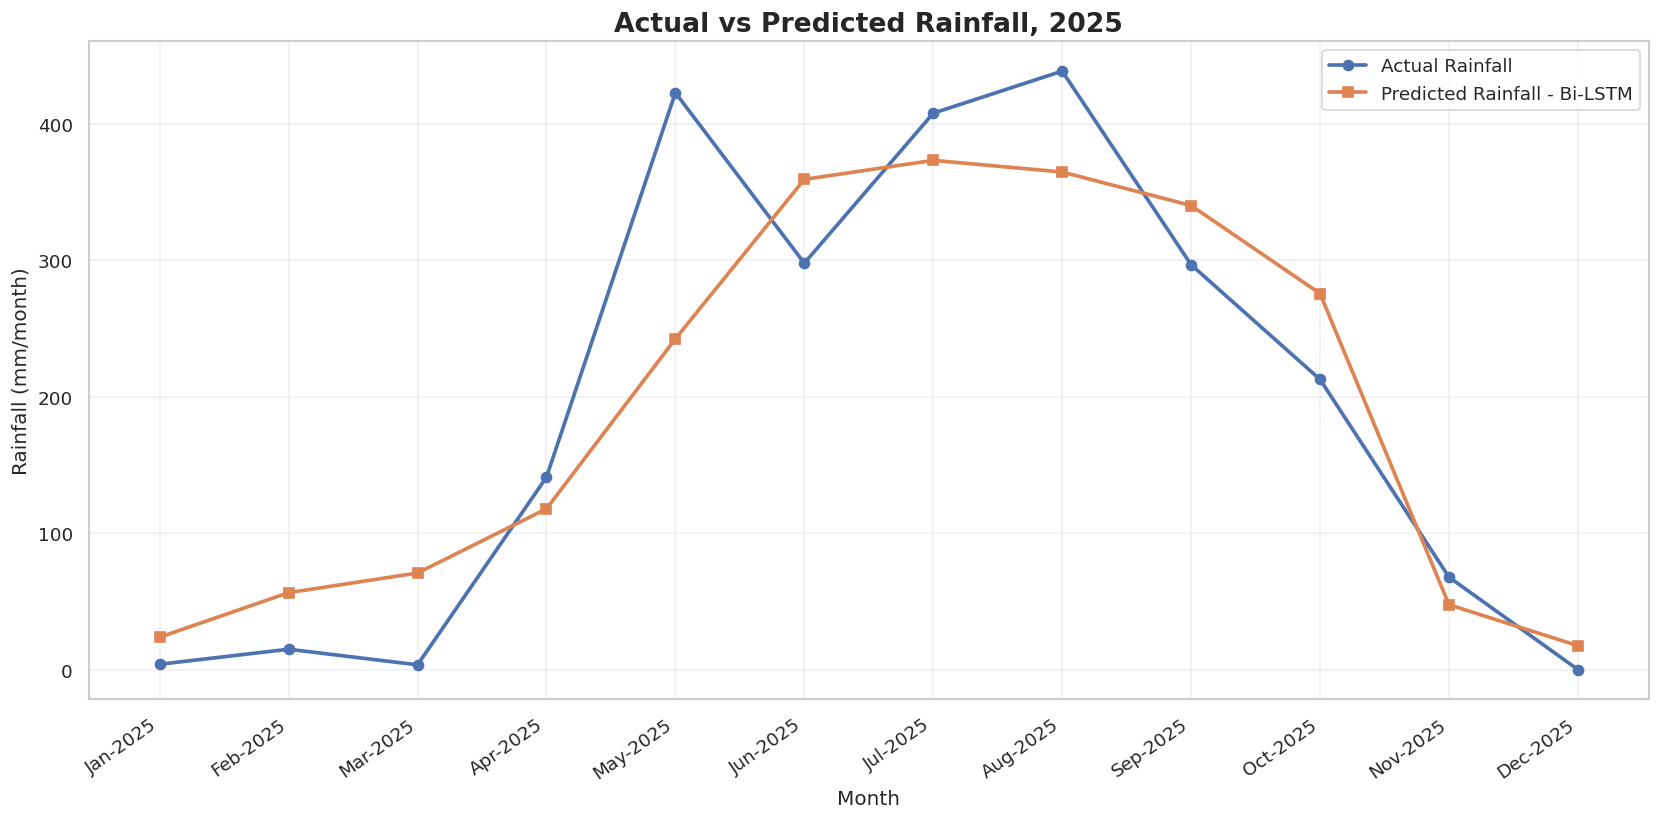

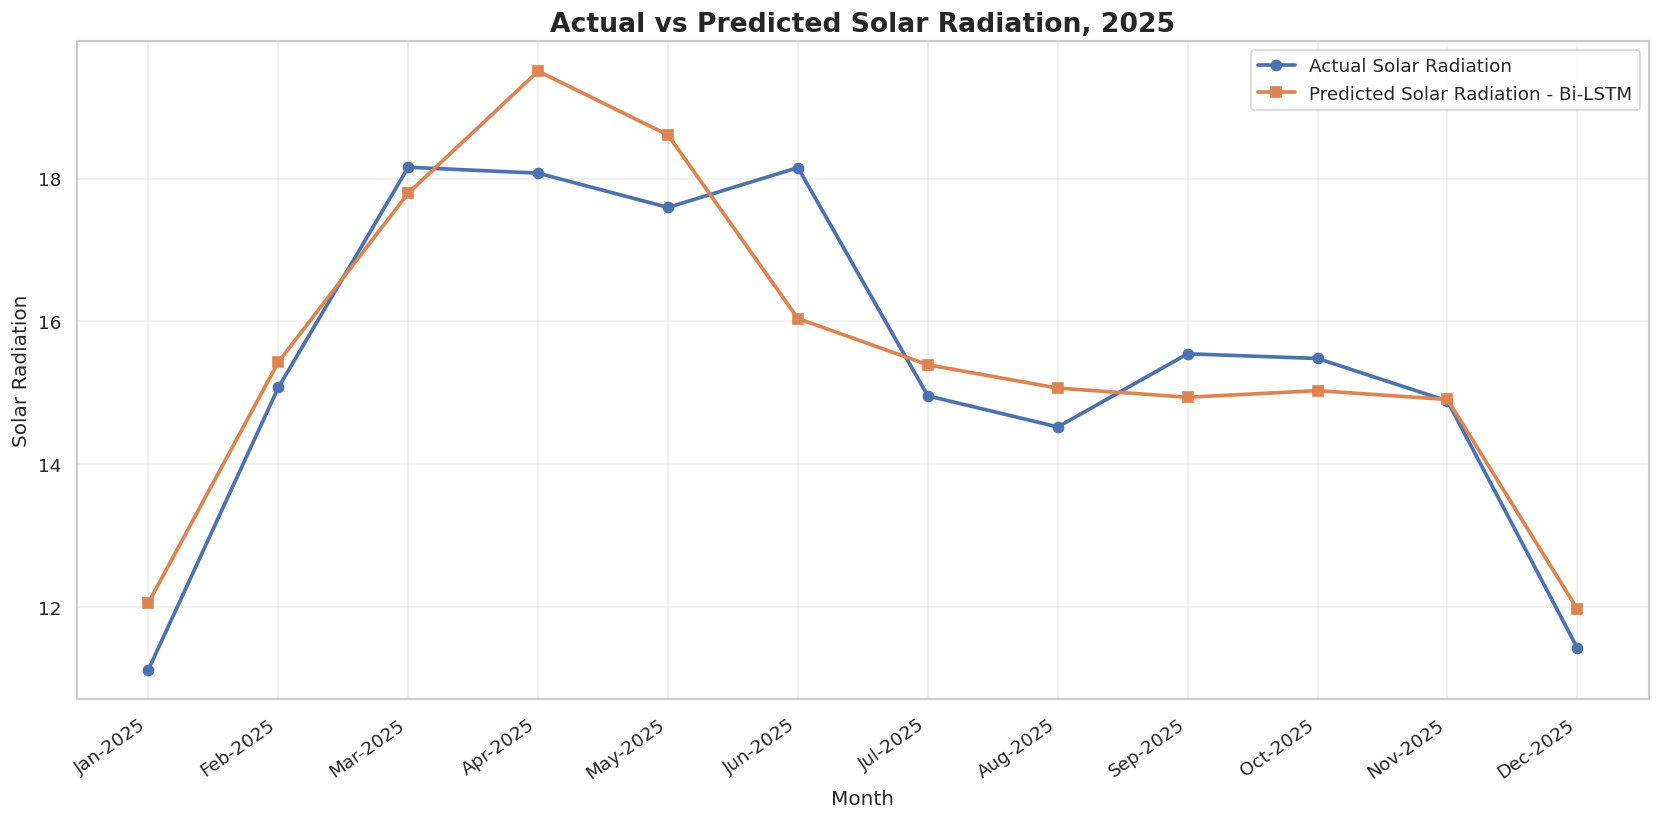

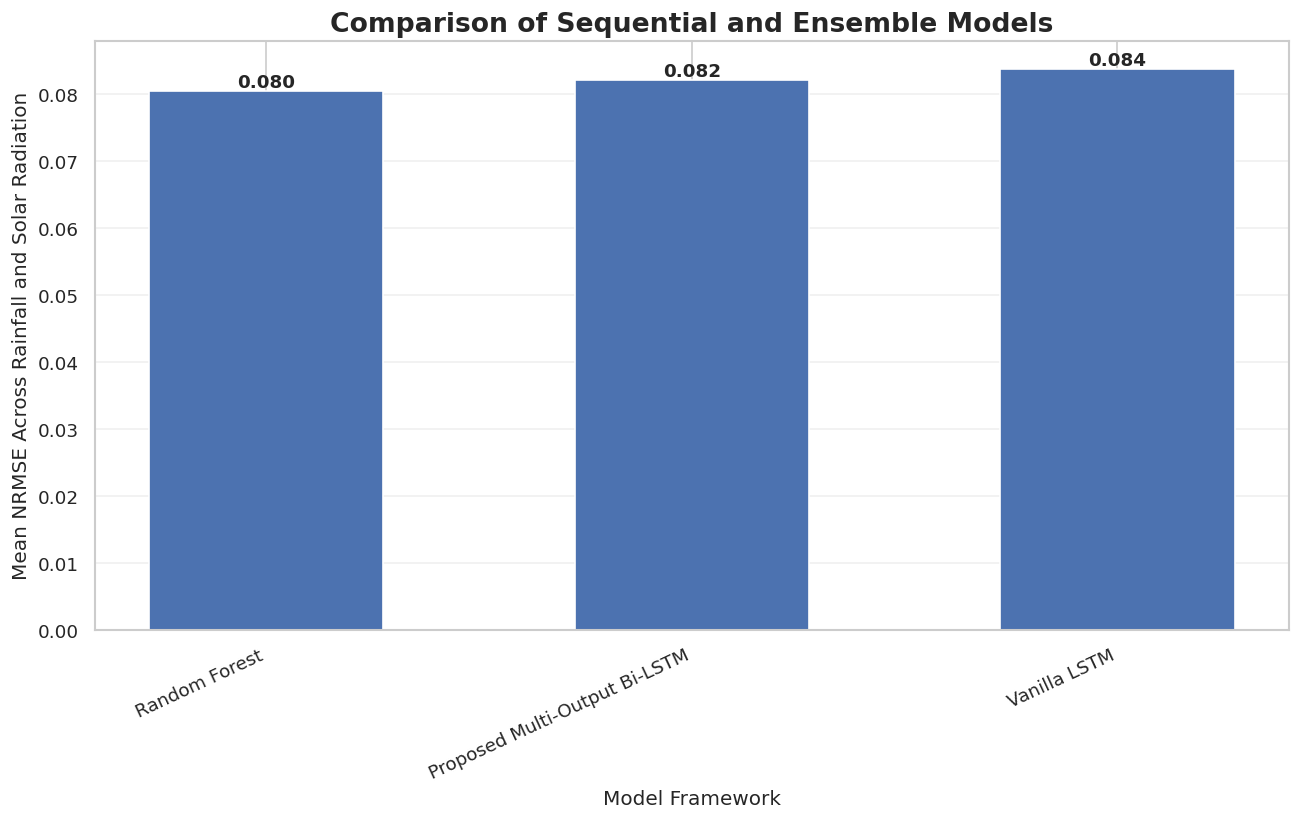

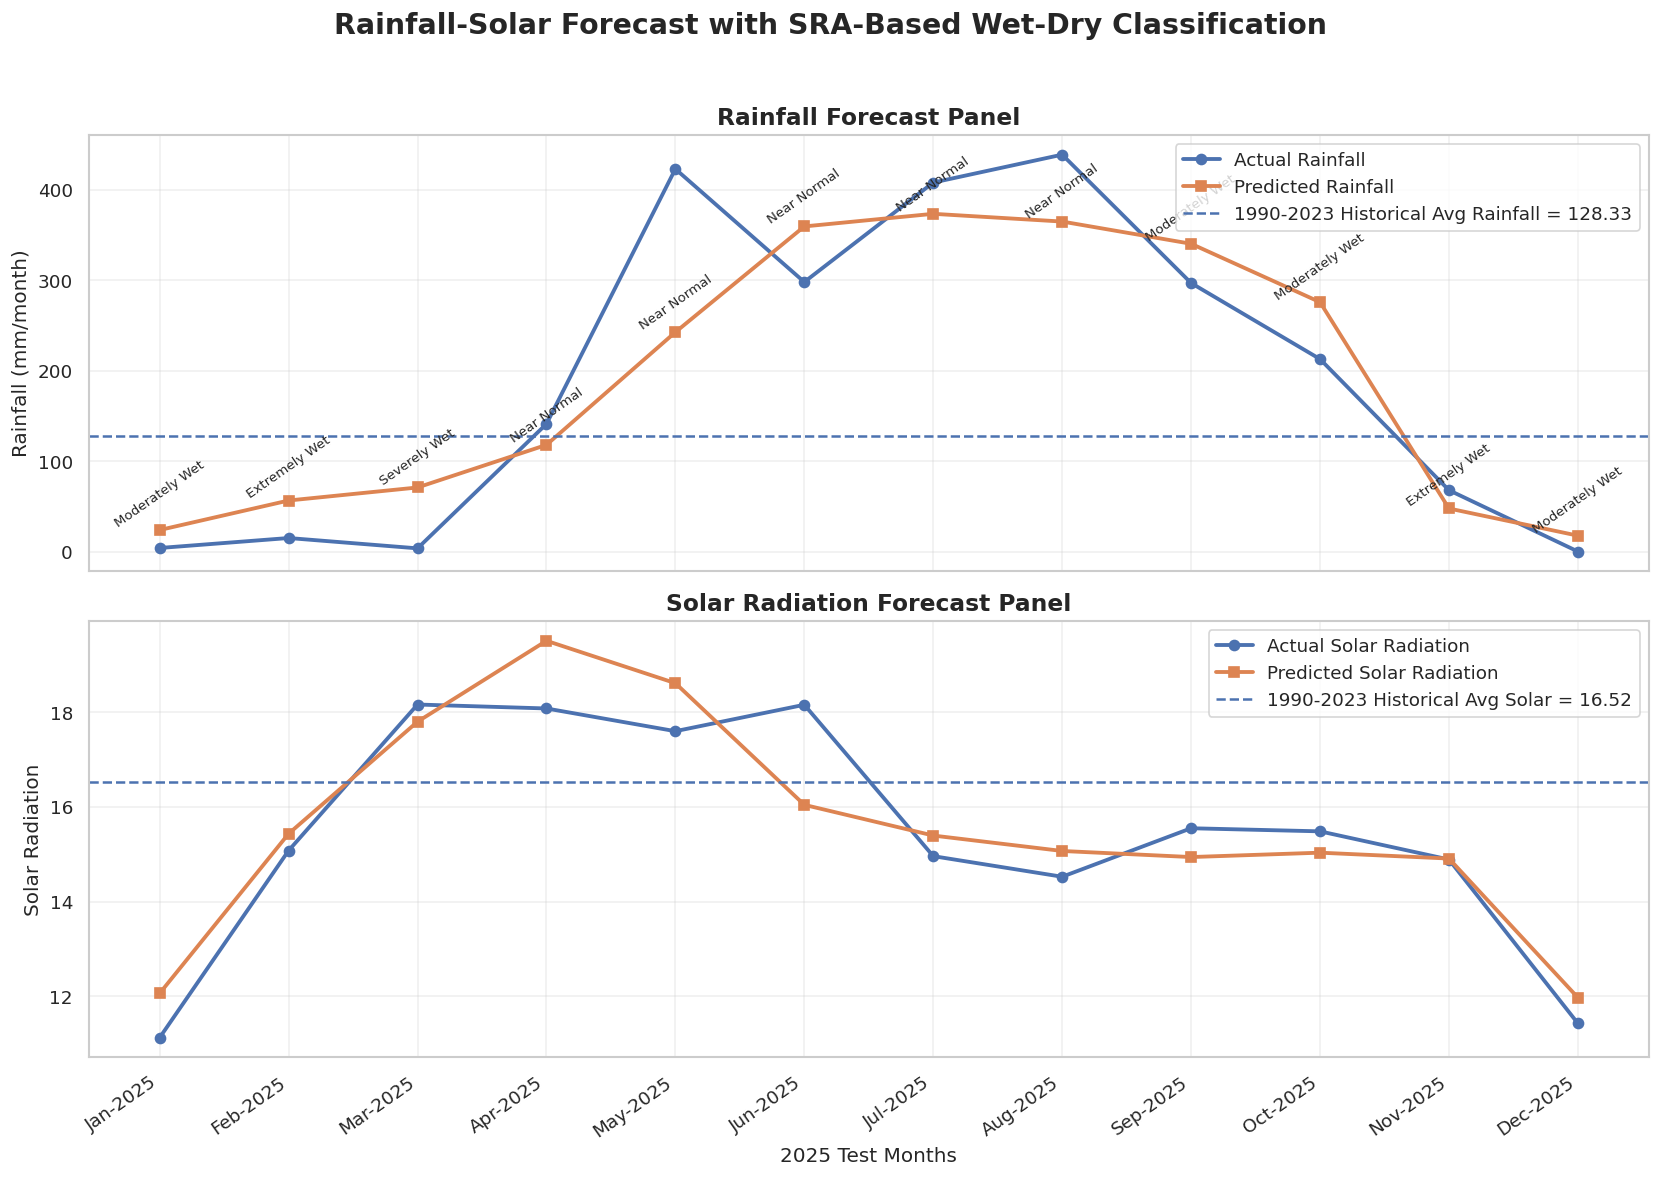

In [2]:
# Bogura Monthly Rainfall + Solar Radiation Forecasting, 2025
# ________________________________________________________________

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except ModuleNotFoundError:
    sns = None
    SEABORN_AVAILABLE = False

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.initializers import GlorotUniform, Orthogonal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


# ________________________________________________________________
# Reproducibility, Paths, and Configuration
# ________________________________________________________________

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")


def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


set_all_seeds(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

if SEABORN_AVAILABLE:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.style.use("default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "DejaVu Sans"

DATA_PATH = Path(r"G:\Z. Khulna 2026 data\Bogra_Daily_Weather Data.csv")
FALLBACK_DATA_PATH = Path("Bogra_Daily_Weather Data.csv")
OUTPUT_DIR = Path("Bogra_outputs_LSTM").resolve()

def ensure_output_dir():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    if not OUTPUT_DIR.is_dir():
        raise RuntimeError(f"Output path exists but is not a directory: {OUTPUT_DIR}")
    return OUTPUT_DIR

ensure_output_dir() 

TARGET_COLS = ["rainfall", "solar_radiation"]
LOOK_BACK = 12
EPOCHS = 150
PATIENCE = 20
DROPOUT_RATE = 0.2
MAX_INTERPOLATION_GAP_DAYS = 3
LEARNING_RATES = [0.01, 0.003, 0.001, 0.0005]
BATCH_SIZES = [16, 32, 64]
RF_PARAMETER_GRID = {
    "n_estimators": [300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4],
}

RENAME_MAP = {
    "YEAR": "year",
    "DOY": "day",
    "ALLSKY_SFC_SW_DWN": "solar_radiation",
    "RH2M": "humidity",
    "T2M_MIN": "temp_min",
    "T2M_MAX": "temp_max",
    "PRECTOTCORR": "rainfall",
}

REQUIRED_RAW_COLS = list(RENAME_MAP.keys())
REQUIRED_MONTHLY_COLS = ["rainfall", "solar_radiation", "humidity", "temp_min", "temp_max", "temp"]


# ________________________________________________________________
# 1. Data Loading, Cleaning, Interpolation, and Monthly Aggregation
# ________________________________________________________________

def resolve_dataset_path() -> Path:
    if DATA_PATH.exists():
        return DATA_PATH
    if FALLBACK_DATA_PATH.exists():
        return FALLBACK_DATA_PATH
    raise FileNotFoundError(
        f"Dataset not found at:\n1) {DATA_PATH}\n2) {FALLBACK_DATA_PATH.resolve()}\n"
    )


def read_nasa_power_csv(csv_path: Path) -> pd.DataFrame:
    try:
        df = pd.read_csv(csv_path)
        if all(col in df.columns for col in REQUIRED_RAW_COLS):
            return df
    except Exception:
        pass

    df = pd.read_csv(csv_path, comment="#")
    if all(col in df.columns for col in REQUIRED_RAW_COLS):
        return df

    with open(csv_path, "r", encoding="utf-8", errors="ignore") as file:
        lines = file.readlines()

    header_index = None
    for idx, line in enumerate(lines):
        columns = [x.strip() for x in line.strip().split(",")]
        if "YEAR" in columns and "DOY" in columns:
            header_index = idx
            break

    if header_index is None:
        raise ValueError("Could not locate NASA POWER header row containing YEAR and DOY.")

    df = pd.read_csv(csv_path, skiprows=header_index)
    return df


def _causal_impute_daily_data(raw_df: pd.DataFrame, interpolation_cols):
    """Impute daily gaps without using validation/test observations as reference data.
    Short gaps are forward-filled from earlier observations. Any remaining values are filled using calendar-month medians estimated only 
    from the 1990-2023 training period."""
    
    df_clean = raw_df.sort_values("date").copy()
    missing_before = df_clean[interpolation_cols].isna().sum()

    # Past-only filling for short gaps.
    df_clean[interpolation_cols] = df_clean[interpolation_cols].ffill(
        limit=MAX_INTERPOLATION_GAP_DAYS
    )

    train_mask = df_clean["date"].dt.year.between(1990, 2023)
    if train_mask.sum() == 0:
        raise ValueError("No daily observations were found in the 1990-2023 training period.")

    calendar_month = df_clean["date"].dt.month
    training_reference = (
        df_clean.loc[train_mask, interpolation_cols]
        .assign(calendar_month=calendar_month.loc[train_mask].values)
        .groupby("calendar_month")[interpolation_cols]
        .median()
    )
    training_overall_median = df_clean.loc[train_mask, interpolation_cols].median()

    for col in interpolation_cols:
        monthly_fill = calendar_month.map(training_reference[col])
        df_clean[col] = df_clean[col].fillna(monthly_fill)
        df_clean[col] = df_clean[col].fillna(training_overall_median[col])

    remaining_missing = df_clean[interpolation_cols].isna().sum()
    if remaining_missing.any():
        raise ValueError(
            "Missing values remain after causal imputation:\n"
            + remaining_missing[remaining_missing > 0].to_string()
        )

    missing_report = pd.DataFrame(
        {
            "variable": interpolation_cols,
            "missing_before": missing_before.values,
            "missing_after": remaining_missing.values,
        }
    )
    missing_report["values_imputed"] = (
        missing_report["missing_before"] - missing_report["missing_after"]
    )
    missing_report["imputation_method"] = (
        f"Past-only forward fill up to {MAX_INTERPOLATION_GAP_DAYS} days; "
        "remaining values filled by 1990-2023 calendar-month median"
    )
    return df_clean, missing_report


def load_and_preprocess_daily_data():
    csv_path = resolve_dataset_path()
    raw_df = read_nasa_power_csv(csv_path)

    missing_raw_cols = [col for col in REQUIRED_RAW_COLS if col not in raw_df.columns]
    if missing_raw_cols:
        raise ValueError(f"Missing required raw columns in CSV: {missing_raw_cols}")

    raw_df = raw_df[REQUIRED_RAW_COLS].copy()
    raw_df = raw_df.rename(columns=RENAME_MAP)

    numeric_cols = ["year", "day", "solar_radiation", "humidity", "temp_min", "temp_max", "rainfall"]
    for col in numeric_cols:
        raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

    raw_df = raw_df.replace(-999, np.nan)
    raw_df = raw_df.dropna(subset=["year", "day"]).copy()
    raw_df["date"] = pd.to_datetime(
        raw_df["year"].astype(int).astype(str),
        format="%Y",
        errors="coerce",
    ) + pd.to_timedelta(raw_df["day"].astype(int) - 1, unit="D")

    raw_df = raw_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
    raw_before_interpolation = raw_df.copy()

    interpolation_cols = ["solar_radiation", "humidity", "temp_min", "temp_max", "rainfall"]
    df_clean, missing_report = _causal_impute_daily_data(raw_df, interpolation_cols)

    df_clean["temp"] = (df_clean["temp_min"] + df_clean["temp_max"]) / 2.0
    df_clean["month_date"] = df_clean["date"].dt.to_period("M").dt.to_timestamp()

    monthly_climate = (
        df_clean
        .groupby("month_date", as_index=False)
        .agg(
            rainfall=("rainfall", "sum"),
            solar_radiation=("solar_radiation", "mean"),
            humidity=("humidity", "mean"),
            temp_min=("temp_min", "mean"),
            temp_max=("temp_max", "mean"),
            temp=("temp", "mean"),
        )
        .sort_values("month_date")
        .reset_index(drop=True)
    )

    monthly_climate["year"] = monthly_climate["month_date"].dt.year
    monthly_climate["month"] = monthly_climate["month_date"].dt.month

    monthly_model = monthly_climate.copy()
    monthly_model["month_sin"] = np.sin(2 * np.pi * monthly_model["month"] / 12)
    monthly_model["month_cos"] = np.cos(2 * np.pi * monthly_model["month"] / 12)
    monthly_model["rainfall_lag1"] = monthly_model["rainfall"].shift(1)
    monthly_model["rainfall_lag12"] = monthly_model["rainfall"].shift(12)
    monthly_model["solar_lag1"] = monthly_model["solar_radiation"].shift(1)
    monthly_model["solar_lag12"] = monthly_model["solar_radiation"].shift(12)
    monthly_model["rainfall_roll3"] = monthly_model["rainfall"].rolling(
        window=3, min_periods=3
    ).mean()
    monthly_model["solar_roll3"] = monthly_model["solar_radiation"].rolling(
        window=3, min_periods=3
    ).mean()

    engineered_cols = [
        "rainfall_lag1",
        "rainfall_lag12",
        "solar_lag1",
        "solar_lag12",
        "rainfall_roll3",
        "solar_roll3",
    ]
    # Never backfill lagged predictors. Initial rows without real historical values are dropped.
    monthly_model = monthly_model.dropna(subset=engineered_cols).reset_index(drop=True)

    return (
        raw_df,
        raw_before_interpolation,
        df_clean,
        monthly_climate,
        monthly_model,
        missing_report,
    )


def make_scaled_sequences(monthly_df, feature_cols, target_cols, look_back):
    train_monthly_mask = (monthly_df["month_date"].dt.year >= 1990) & (monthly_df["month_date"].dt.year <= 2023)
    if train_monthly_mask.sum() < look_back + 12:
        raise ValueError("Training period has too few monthly records for a 12-month look-back model.")

    scaler_X = MinMaxScaler()
    scaler_Y = MinMaxScaler()

    scaler_X.fit(monthly_df.loc[train_monthly_mask, feature_cols])
    scaler_Y.fit(monthly_df.loc[train_monthly_mask, target_cols])

    X_scaled_full = scaler_X.transform(monthly_df[feature_cols])
    y_scaled_full = scaler_Y.transform(monthly_df[target_cols])

    X_seq, y_seq, target_dates = [], [], []
    for i in range(look_back, len(monthly_df)):
        X_seq.append(X_scaled_full[i - look_back:i, :])
        y_seq.append(y_scaled_full[i, :])
        target_dates.append(monthly_df.loc[i, "month_date"])

    X_seq = np.asarray(X_seq, dtype=np.float32)
    y_seq = np.asarray(y_seq, dtype=np.float32)
    target_dates = pd.to_datetime(pd.Series(target_dates))

    train_mask = (target_dates.dt.year >= 1990) & (target_dates.dt.year <= 2023)
    val_mask = target_dates.dt.year == 2024
    test_mask = target_dates.dt.year == 2025

    X_train, y_train = X_seq[train_mask.values], y_seq[train_mask.values]
    X_val, y_val = X_seq[val_mask.values], y_seq[val_mask.values]
    X_test, y_test = X_seq[test_mask.values], y_seq[test_mask.values]

    dates_train = target_dates[train_mask.values].reset_index(drop=True)
    dates_val = target_dates[val_mask.values].reset_index(drop=True)
    dates_test = target_dates[test_mask.values].reset_index(drop=True)

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        raise ValueError(
            f"Invalid split sizes: train={len(X_train)}, validation={len(X_val)}, test={len(X_test)}. "
            "Confirm the dataset contains complete 1990-2025 monthly coverage."
        )

    return X_train, y_train, X_val, y_val, X_test, y_test, dates_train, dates_val, dates_test, scaler_X, scaler_Y


# ________________________________________________________________
# 2. Model Builders and Evaluation 
# ________________________________________________________________

def build_bilstm_model(input_shape, learning_rate=0.001, model_seed=SEED):
    model = Sequential(
        [
            Bidirectional(
                LSTM(
                    128,
                    return_sequences=True,
                    dropout=0.2,
                    recurrent_dropout=0.1,
                    kernel_initializer=GlorotUniform(seed=model_seed),
                    recurrent_initializer=Orthogonal(seed=model_seed),
                    bias_initializer="zeros",
                ),
                input_shape=input_shape,
            ),
            BatchNormalization(),
            Bidirectional(
                LSTM(
                    64,
                    return_sequences=False,
                    dropout=0.2,
                    recurrent_dropout=0.1,
                    kernel_initializer=GlorotUniform(seed=model_seed + 1),
                    recurrent_initializer=Orthogonal(seed=model_seed + 1),
                    bias_initializer="zeros",
                )
            ),
            Dropout(DROPOUT_RATE, seed=model_seed + 2),
            Dense(
                32,
                activation="tanh",
                kernel_initializer=GlorotUniform(seed=model_seed + 3),
                bias_initializer="zeros",
            ),
            Dense(
                2,
                activation="linear",
                kernel_initializer=GlorotUniform(seed=model_seed + 4),
                bias_initializer="zeros",
            ),
        ]
    )
    model.compile(
        optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"],
    )
    return model


def build_vanilla_lstm_model(input_shape, learning_rate=0.001, model_seed=SEED):
    model = Sequential(
        [
            LSTM(
                64,
                return_sequences=False,
                kernel_initializer=GlorotUniform(seed=model_seed),
                recurrent_initializer=Orthogonal(seed=model_seed),
                bias_initializer="zeros",
                input_shape=input_shape,
            ),
            Dropout(DROPOUT_RATE, seed=model_seed + 1),
            Dense(
                32,
                activation="tanh",
                kernel_initializer=GlorotUniform(seed=model_seed + 2),
                bias_initializer="zeros",
            ),
            Dense(
                2,
                activation="linear",
                kernel_initializer=GlorotUniform(seed=model_seed + 3),
                bias_initializer="zeros",
            ),
        ]
    )
    model.compile(
        optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"],
    )
    return model


def train_keras_model(model, X_train, y_train, X_val, y_val, batch_size):
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=0,
    )
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0,
        shuffle=False,
    )
    return history


def inverse_transform_predictions(scaler_Y, y_scaled):
    return scaler_Y.inverse_transform(np.asarray(y_scaled))


def target_error_summary(y_true, y_pred, target_ranges):
    """Return target-wise errors and a unit-free mean NRMSE for model selection."""
    target_ranges = np.asarray(target_ranges, dtype=float)
    if np.any(target_ranges <= 0):
        raise ValueError("Every target must have a positive training range for NRMSE.")

    target_rmse = np.asarray(
        [
            np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
            for i in range(len(TARGET_COLS))
        ],
        dtype=float,
    )
    target_nrmse = target_rmse / target_ranges
    return target_rmse, target_nrmse, float(np.mean(target_nrmse))


def calculate_metrics(y_true, y_pred, model_name, target_ranges):
    rows = []
    target_ranges = np.asarray(target_ranges, dtype=float)
    for i, target in enumerate(TARGET_COLS):
        rmse = float(np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])))
        mae = float(mean_absolute_error(y_true[:, i], y_pred[:, i]))
        r2 = float(r2_score(y_true[:, i], y_pred[:, i]))
        rows.append(
            {
                "Model": model_name,
                "Target": target,
                "RMSE": rmse,
                "MAE": mae,
                "R2": r2,
                "NRMSE_train_range": rmse / target_ranges[i],
                "NMAE_train_range": mae / target_ranges[i],
            }
        )

    rows.append(
        {
            "Model": model_name,
            "Target": "Mean normalized score",
            "RMSE": np.nan,
            "MAE": np.nan,
            "R2": np.nan,
            "NRMSE_train_range": float(np.mean([row["NRMSE_train_range"] for row in rows])),
            "NMAE_train_range": float(np.mean([row["NMAE_train_range"] for row in rows])),
        }
    )
    return pd.DataFrame(rows)


def add_value_labels(ax, values, fmt="{:.4f}"):
    for idx, value in enumerate(values):
        ax.text(idx, value, fmt.format(value), ha="center", va="bottom", fontsize=10)


# ________________________________________________________________
# 3. Main workflow of the study
# ________________________________________________________________

def main():
    ensure_output_dir()
    print("\nLoading and preprocessing Bogura NASA POWER dataset...")
    (
        raw_df,
        raw_before_interp,
        daily_clean,
        monthly_climate,
        monthly,
        missing_report,
    ) = load_and_preprocess_daily_data()
    missing_report.to_csv(OUTPUT_DIR / "bogura_missing_data_imputation_report.csv", index=False)

    feature_cols = [
        "rainfall",
        "solar_radiation",
        "humidity",
        "temp_min",
        "temp_max",
        "temp",
        "month_sin",
        "month_cos",
        "rainfall_lag1",
        "rainfall_lag12",
        "solar_lag1",
        "solar_lag12",
        "rainfall_roll3",
        "solar_roll3",
    ]

    X_train, y_train, X_val, y_val, X_test, y_test, dates_train, dates_val, dates_test, scaler_X, scaler_Y = make_scaled_sequences(
        monthly,
        feature_cols,
        TARGET_COLS,
        LOOK_BACK,
    )

    print("\nDataset partitions:")
    print(f"Train:      {dates_train.min().date()} to {dates_train.max().date()} | samples={len(X_train)}")
    print(f"Validation: {dates_val.min().date()} to {dates_val.max().date()} | samples={len(X_val)}")
    print(f"Test:       {dates_test.min().date()} to {dates_test.max().date()} | samples={len(X_test)}")

    y_test_actual = inverse_transform_predictions(scaler_Y, y_test)
    target_ranges = scaler_Y.data_range_.astype(float)

    train_monthly = monthly_climate[
        (monthly_climate["year"] >= 1990) & (monthly_climate["year"] <= 2023)
    ].copy()
    historical_avg_rainfall = float(train_monthly["rainfall"].mean())
    historical_avg_solar = float(train_monthly["solar_radiation"].mean())

    print("\nTraining baseline averages from 1990-2023:")
    print(f"Historical Average Monthly Rainfall: {historical_avg_rainfall:.4f}")
    print(f"Historical Average Monthly Solar Radiation: {historical_avg_solar:.4f}")

    print("\nRunning Bi-LSTM hyperparameter diagnostics...")
    tuning_records = []
    history_store = {}
    best_bilstm_score = np.inf
    BEST_LR = None
    BEST_BATCH_SIZE = None

    input_shape = (X_train.shape[1], X_train.shape[2])
    val_actual = inverse_transform_predictions(scaler_Y, y_val)

    for lr in LEARNING_RATES:
        for batch_size in BATCH_SIZES:
            tf.keras.backend.clear_session()
            set_all_seeds(SEED)
            diagnostic_model = build_bilstm_model(
                input_shape=input_shape,
                learning_rate=lr,
                model_seed=SEED,
            )
            diagnostic_history = train_keras_model(
                diagnostic_model,
                X_train,
                y_train,
                X_val,
                y_val,
                batch_size=batch_size,
            )

            val_pred_scaled = diagnostic_model.predict(X_val, verbose=0)
            val_pred = inverse_transform_predictions(scaler_Y, val_pred_scaled)
            val_rmse, val_nrmse, val_mean_nrmse = target_error_summary(
                val_actual,
                val_pred,
                target_ranges,
            )

            best_val_loss = float(np.min(diagnostic_history.history["val_loss"]))
            final_train_loss = float(diagnostic_history.history["loss"][-1])
            key = f"lr_{lr}_batch_{batch_size}"
            history_store[key] = diagnostic_history.history

            tuning_records.append(
                {
                    "learning_rate": lr,
                    "batch_size": batch_size,
                    "epochs_trained": len(diagnostic_history.history["loss"]),
                    "best_validation_huber_loss": best_val_loss,
                    "final_training_huber_loss": final_train_loss,
                    "validation_rainfall_rmse": val_rmse[0],
                    "validation_solar_rmse": val_rmse[1],
                    "validation_rainfall_nrmse": val_nrmse[0],
                    "validation_solar_nrmse": val_nrmse[1],
                    "validation_mean_nrmse": val_mean_nrmse,
                }
            )

            if val_mean_nrmse < best_bilstm_score:
                best_bilstm_score = val_mean_nrmse
                BEST_LR = lr
                BEST_BATCH_SIZE = batch_size

            print(
                f"Finished Bi-LSTM diagnostic: lr={lr}, batch={batch_size}, "
                f"best_val_huber={best_val_loss:.6f}, mean_NRMSE={val_mean_nrmse:.4f}"
            )

    tuning_df = pd.DataFrame(tuning_records)
    tuning_df.to_csv(OUTPUT_DIR / "bogura_bilstm_hyperparameter_summary.csv", index=False)

    print(
        f"\nBest selected Bi-LSTM configuration: LR={BEST_LR}, "
        f"Batch Size={BEST_BATCH_SIZE}, Validation Mean NRMSE={best_bilstm_score:.4f}"
    )

    # ________________________________________________________________
    # Repeated Seed Experiment for Robustness
    # ________________________________________________________________
    SEED_LIST = [7, 21, 42, 84, 123]
    seed_results = []

    print("\nRunning repeated-seed experiment for the selected Bi-LSTM configuration...")
    for run_seed in SEED_LIST:
        tf.keras.backend.clear_session()
        set_all_seeds(run_seed)
        seed_model = build_bilstm_model(
            input_shape=input_shape,
            learning_rate=BEST_LR,
            model_seed=run_seed,
        )
        train_keras_model(
            seed_model,
            X_train,
            y_train,
            X_val,
            y_val,
            batch_size=BEST_BATCH_SIZE,
        )

        seed_pred_scaled = seed_model.predict(X_test, verbose=0)
        seed_pred = inverse_transform_predictions(scaler_Y, seed_pred_scaled)
        seed_pred[:, 0] = np.maximum(seed_pred[:, 0], 0)
        seed_results.append(
            calculate_metrics(
                y_test_actual,
                seed_pred,
                f"Bi-LSTM Seed {run_seed}",
                target_ranges,
            )
        )

    seed_metrics_df = pd.concat(seed_results, ignore_index=True)
    seed_metrics_df.to_csv(OUTPUT_DIR / "bilstm_repeated_seed_metrics.csv", index=False)
    seed_summary_df = (
        seed_metrics_df
        .groupby("Target")[["RMSE", "MAE", "R2", "NRMSE_train_range", "NMAE_train_range"]]
        .agg(["mean", "std"])
        .round(4)
    )
    seed_summary_df.to_csv(OUTPUT_DIR / "bilstm_repeated_seed_mean_std_summary.csv")
    print("\nRepeated-seed experiment summary: mean ± standard deviation")
    print(seed_summary_df)

    # ________________________________________________________________
    # Rebuild the selected Bi-LSTM  with seed
    # ________________________________________________________________
    tf.keras.backend.clear_session()
    set_all_seeds(SEED)
    proposed_bilstm = build_bilstm_model(
        input_shape=input_shape,
        learning_rate=BEST_LR,
        model_seed=SEED,
    )
    proposed_history_object = train_keras_model(
        proposed_bilstm,
        X_train,
        y_train,
        X_val,
        y_val,
        batch_size=BEST_BATCH_SIZE,
    )
    proposed_history = proposed_history_object.history

    y_pred_bilstm_scaled = proposed_bilstm.predict(X_test, verbose=0)
    y_pred_bilstm = inverse_transform_predictions(scaler_Y, y_pred_bilstm_scaled)
    y_pred_bilstm[:, 0] = np.maximum(y_pred_bilstm[:, 0], 0)

    # ________________________________________________________________
    # Tune the Vanilla LSTM baseline on the same validation period
    # ________________________________________________________________
    print("\nTuning Vanilla LSTM baseline...")
    vanilla_tuning_records = []
    best_vanilla_score = np.inf
    BEST_VANILLA_LR = None
    BEST_VANILLA_BATCH = None

    for lr in LEARNING_RATES:
        for batch_size in BATCH_SIZES:
            tf.keras.backend.clear_session()
            set_all_seeds(SEED)
            candidate = build_vanilla_lstm_model(
                input_shape=input_shape,
                learning_rate=lr,
                model_seed=SEED + 100,
            )
            candidate_history = train_keras_model(
                candidate,
                X_train,
                y_train,
                X_val,
                y_val,
                batch_size=batch_size,
            )
            candidate_val_scaled = candidate.predict(X_val, verbose=0)
            candidate_val = inverse_transform_predictions(scaler_Y, candidate_val_scaled)
            candidate_rmse, candidate_nrmse, candidate_mean_nrmse = target_error_summary(
                val_actual,
                candidate_val,
                target_ranges,
            )
            vanilla_tuning_records.append(
                {
                    "learning_rate": lr,
                    "batch_size": batch_size,
                    "epochs_trained": len(candidate_history.history["loss"]),
                    "best_validation_huber_loss": float(np.min(candidate_history.history["val_loss"])),
                    "validation_rainfall_rmse": candidate_rmse[0],
                    "validation_solar_rmse": candidate_rmse[1],
                    "validation_rainfall_nrmse": candidate_nrmse[0],
                    "validation_solar_nrmse": candidate_nrmse[1],
                    "validation_mean_nrmse": candidate_mean_nrmse,
                }
            )
            if candidate_mean_nrmse < best_vanilla_score:
                best_vanilla_score = candidate_mean_nrmse
                BEST_VANILLA_LR = lr
                BEST_VANILLA_BATCH = batch_size

    vanilla_tuning_df = pd.DataFrame(vanilla_tuning_records)
    vanilla_tuning_df.to_csv(OUTPUT_DIR / "vanilla_lstm_hyperparameter_summary.csv", index=False)

    tf.keras.backend.clear_session()
    set_all_seeds(SEED + 100)
    vanilla_lstm = build_vanilla_lstm_model(
        input_shape=input_shape,
        learning_rate=BEST_VANILLA_LR,
        model_seed=SEED + 100,
    )
    train_keras_model(
        vanilla_lstm,
        X_train,
        y_train,
        X_val,
        y_val,
        batch_size=BEST_VANILLA_BATCH,
    )
    y_pred_vanilla_scaled = vanilla_lstm.predict(X_test, verbose=0)
    y_pred_vanilla = inverse_transform_predictions(scaler_Y, y_pred_vanilla_scaled)
    y_pred_vanilla[:, 0] = np.maximum(y_pred_vanilla[:, 0], 0)
    print(
        f"Best Vanilla LSTM: LR={BEST_VANILLA_LR}, Batch={BEST_VANILLA_BATCH}, "
        f"Validation Mean NRMSE={best_vanilla_score:.4f}"
    )

    # ________________________________________________________________
    # Tune the Random Forest baseline on the same validation period
    # ________________________________________________________________
    print("\nTuning Random Forest baseline...")
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_val_flat = X_val.reshape(X_val.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)
    rf_tuning_records = []
    best_rf_score = np.inf
    BEST_RF_PARAMS = None

    for n_estimators in RF_PARAMETER_GRID["n_estimators"]:
        for max_depth in RF_PARAMETER_GRID["max_depth"]:
            for min_samples_leaf in RF_PARAMETER_GRID["min_samples_leaf"]:
                candidate_rf = RandomForestRegressor(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    random_state=SEED,
                    n_jobs=-1,
                )
                candidate_rf.fit(X_train_flat, y_train)
                rf_val_scaled = candidate_rf.predict(X_val_flat)
                rf_val = inverse_transform_predictions(scaler_Y, rf_val_scaled)
                rf_rmse, rf_nrmse, rf_mean_nrmse = target_error_summary(
                    val_actual,
                    rf_val,
                    target_ranges,
                )
                rf_tuning_records.append(
                    {
                        "n_estimators": n_estimators,
                        "max_depth": max_depth,
                        "min_samples_leaf": min_samples_leaf,
                        "validation_rainfall_rmse": rf_rmse[0],
                        "validation_solar_rmse": rf_rmse[1],
                        "validation_rainfall_nrmse": rf_nrmse[0],
                        "validation_solar_nrmse": rf_nrmse[1],
                        "validation_mean_nrmse": rf_mean_nrmse,
                    }
                )
                if rf_mean_nrmse < best_rf_score:
                    best_rf_score = rf_mean_nrmse
                    BEST_RF_PARAMS = {
                        "n_estimators": n_estimators,
                        "max_depth": max_depth,
                        "min_samples_leaf": min_samples_leaf,
                    }

    rf_tuning_df = pd.DataFrame(rf_tuning_records)
    rf_tuning_df.to_csv(OUTPUT_DIR / "random_forest_hyperparameter_summary.csv", index=False)

    random_forest = RandomForestRegressor(
        n_estimators=BEST_RF_PARAMS["n_estimators"],
        max_depth=BEST_RF_PARAMS["max_depth"],
        min_samples_leaf=BEST_RF_PARAMS["min_samples_leaf"],
        random_state=SEED,
        n_jobs=-1,
    )
    random_forest.fit(X_train_flat, y_train)
    y_pred_rf_scaled = random_forest.predict(X_test_flat)
    y_pred_rf = inverse_transform_predictions(scaler_Y, y_pred_rf_scaled)
    y_pred_rf[:, 0] = np.maximum(y_pred_rf[:, 0], 0)
    print(f"Best Random Forest parameters: {BEST_RF_PARAMS}; Validation Mean NRMSE={best_rf_score:.4f}")

    bilstm_metrics = calculate_metrics(
        y_test_actual,
        y_pred_bilstm,
        "Proposed Multi-Output Bi-LSTM",
        target_ranges,
    )
    vanilla_metrics = calculate_metrics(
        y_test_actual,
        y_pred_vanilla,
        "Vanilla LSTM",
        target_ranges,
    )
    rf_metrics = calculate_metrics(
        y_test_actual,
        y_pred_rf,
        "Random Forest",
        target_ranges,
    )
    performance_df = pd.concat([bilstm_metrics, vanilla_metrics, rf_metrics], ignore_index=True)
    performance_df.to_csv(OUTPUT_DIR / "bogura_model_performance_metrics.csv", index=False)

    prediction_df = pd.DataFrame(
        {
            "month_date": dates_test.dt.strftime("%Y-%m-%d"),
            "actual_rainfall": y_test_actual[:, 0],
            "predicted_rainfall_bilstm": y_pred_bilstm[:, 0],
            "actual_solar_radiation": y_test_actual[:, 1],
            "predicted_solar_radiation_bilstm": y_pred_bilstm[:, 1],
        }
    )

    prediction_df["historical_avg_rainfall_1990_2023"] = historical_avg_rainfall
    prediction_df["historical_avg_solar_radiation_1990_2023"] = historical_avg_solar

    # ________________________________________________________________
    # SRA-Based Wet-Dry Rainfall Anomaly Assessment
    # ________________________________________________________________
    """ Literature-based: Standardized Rainfall Anomaly (SRA)
    Simplified monthly SRA = (P - monthly_climatological_mean) / monthly_climatological_std
    Where P is the actual or Bi-LSTM-predicted monthly rainfall, & the reference climatology is calculated from 1990-2023 training data. """
    # ________________________________________________________________
    sra_reference = (
        train_monthly
        .groupby("month")["rainfall"]
        .agg(["mean", "std"])
        .reset_index()
        .rename(
            columns={
                "mean": "monthly_rainfall_mean_1990_2023",
                "std": "monthly_rainfall_std_1990_2023",
            }
        )
    )

    prediction_df["month"] = pd.to_datetime(prediction_df["month_date"]).dt.month
    prediction_df = prediction_df.merge(sra_reference, on="month", how="left")

    # Prevent division-by-zero problems if a monthly standard deviation is zero.
    prediction_df["monthly_rainfall_std_1990_2023"] = prediction_df[
        "monthly_rainfall_std_1990_2023"
    ].replace(0, np.nan)

    prediction_df["actual_sra"] = (
        prediction_df["actual_rainfall"]
        - prediction_df["monthly_rainfall_mean_1990_2023"]
    ) / prediction_df["monthly_rainfall_std_1990_2023"]

    prediction_df["predicted_sra_bilstm"] = (
        prediction_df["predicted_rainfall_bilstm"]
        - prediction_df["monthly_rainfall_mean_1990_2023"]
    ) / prediction_df["monthly_rainfall_std_1990_2023"]

    def classify_sra(sra_value):
        if pd.isna(sra_value):
            return "Undefined"
        if sra_value <= -2.0:
            return "Extremely Dry"
        if sra_value <= -1.5:
            return "Severely Dry"
        if sra_value <= -1.0:
            return "Moderately Dry"
        if sra_value < 1.0:
            return "Near Normal"
        if sra_value < 1.5:
            return "Moderately Wet"
        if sra_value < 2.0:
            return "Severely Wet"
        return "Extremely Wet"

    prediction_df["actual_sra_class"] = prediction_df["actual_sra"].apply(classify_sra)
    prediction_df["predicted_sra_class"] = prediction_df["predicted_sra_bilstm"].apply(classify_sra)
    prediction_df["sra_class_match"] = (
        prediction_df["actual_sra_class"] == prediction_df["predicted_sra_class"]
    )
    sra_class_accuracy = float(prediction_df["sra_class_match"].mean())
    ensure_output_dir()
    prediction_df.to_csv(OUTPUT_DIR / "bogura_2025_bilstm_multioutput_predictions.csv", index=False)

    plot_dates = pd.to_datetime(prediction_df["month_date"])
    plot_month_labels = plot_dates.dt.strftime("%b-%Y").tolist()
    x_idx = np.arange(len(prediction_df))

    ensure_output_dir()

    # ________________________________________________________________
    # Figure 1: Historical Feature Correlation Heatmap
    # ________________________________________________________________

    corr_features = ["rainfall", "temp", "humidity", "solar_radiation"]
    corr_matrix = monthly_climate[corr_features].corr()

    plt.figure(figsize=(10, 8))
    if SEABORN_AVAILABLE:
        sns.heatmap(
            corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.75,
            cbar_kws={"label": "Pearson Correlation"},
        )
        plt.xticks(rotation=35, ha="right")
        plt.yticks(rotation=0)
    else:
        im = plt.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
        cbar = plt.colorbar(im)
        cbar.set_label("Pearson Correlation")
        plt.xticks(np.arange(len(corr_features)), corr_features, rotation=35, ha="right")
        plt.yticks(np.arange(len(corr_features)), corr_features)
        for i in range(len(corr_features)):
            for j in range(len(corr_features)):
                plt.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=11)

    plt.title("Historical Feature Correlation Heatmap - Bogura", fontsize=16, fontweight="bold", pad=15)
    plt.xlabel("Climate Features", fontsize=12)
    plt.ylabel("Climate Features", fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "figure_01_historical_feature_correlation_heatmap.png", bbox_inches="tight")

    # ________________________________________________________________
    # Figure 2: Long-term Time-Series Trend & Seasonality Decomposition Plot
    # ________________________________________________________________

    rainfall_series = monthly_climate.set_index("month_date")["rainfall"].asfreq("MS")
    rainfall_trend = rainfall_series.rolling(window=12, center=True, min_periods=6).mean()
    rainfall_detrended = rainfall_series - rainfall_trend
    monthly_seasonal_means = rainfall_detrended.groupby(rainfall_detrended.index.month).transform("mean")
    rainfall_seasonal = monthly_seasonal_means.fillna(0)
    rainfall_residual = rainfall_series - rainfall_trend - rainfall_seasonal

    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
    axes[0].plot(rainfall_series.index, rainfall_series.values, linewidth=1.4)
    axes[0].set_title("Observed Monthly Rainfall", fontsize=13, fontweight="bold")
    axes[0].set_ylabel("Rainfall (mm/month)")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(rainfall_trend.index, rainfall_trend.values, linewidth=2.0)
    axes[1].set_title("12-Month Rolling Trend", fontsize=13, fontweight="bold")
    axes[1].set_ylabel("Trend")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(rainfall_seasonal.index, rainfall_seasonal.values, linewidth=1.4)
    axes[2].set_title("Estimated Monthly Seasonal Component", fontsize=13, fontweight="bold")
    axes[2].set_ylabel("Seasonality")
    axes[2].grid(True, alpha=0.3)

    axes[3].plot(rainfall_residual.index, rainfall_residual.values, linewidth=1.0)
    axes[3].axhline(0, linestyle="--", linewidth=1)
    axes[3].set_title("Residual Component", fontsize=13, fontweight="bold")
    axes[3].set_ylabel("Residual")
    axes[3].set_xlabel("Date")
    axes[3].grid(True, alpha=0.3)

    fig.suptitle("Long-term Time-Series Trend & Seasonality Decomposition - Bogura Rainfall", fontsize=17, fontweight="bold", y=0.995)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "figure_02_long_term_trend_seasonality_decomposition.png", bbox_inches="tight")

    # ________________________________________________________________
    # Figure 3: Missing Data Data-Quality Check
    # ________________________________________________________________

    quality_start_date = pd.Timestamp("2023-01-01")
    raw_quality = raw_before_interp[raw_before_interp["date"] >= quality_start_date].copy()
    clean_quality = daily_clean[daily_clean["date"] >= quality_start_date].copy()

    plt.figure(figsize=(16, 6))
    plt.plot(
        raw_quality["date"],
        raw_quality["rainfall"],
        marker="o",
        linestyle="None",
        markersize=2.5,
        alpha=0.65,
        label="Raw Daily Rainfall Before Cleaning",
    )
    plt.plot(
        clean_quality["date"],
        clean_quality["rainfall"],
        linewidth=1.2,
        alpha=0.95,
        label="After Causal Imputation",
    )
    plt.title("Missing-Data Quality Check", fontsize=16, fontweight="bold")
    plt.xlabel("Date")
    plt.ylabel("Daily Rainfall (mm/day)")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "Figure 3 Missing-Data Quality Check.png", bbox_inches="tight")

    # ________________________________________________________________
    # Figure 4: Learning Rate Optimization Sensitivity Curve
    # ________________________________________________________________

    plt.figure(figsize=(12, 7))
    for lr in LEARNING_RATES:
        key_for_lr = f"lr_{lr}_batch_{BEST_BATCH_SIZE}"
        history_for_lr = history_store[key_for_lr]
        epochs_range = np.arange(1, len(history_for_lr["loss"]) + 1)
        plt.plot(
            epochs_range,
            history_for_lr["loss"],
            linewidth=2.0,
            label=f"Training Loss, LR={lr}",
        )
        plt.plot(
            epochs_range,
            history_for_lr["val_loss"],
            linestyle="--",
            linewidth=2.0,
            label=f"Validation Loss, LR={lr}",
        )

    plt.title("Learning Rate Optimization Sensitivity Curve", fontsize=16, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Huber Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "Figure 4 Learning Rate Optimization Sensitivity Curve.png", bbox_inches="tight")

    # ________________________________________________________________
    # Figure 5: Selected Bi-LSTM Training and Validation Huber Loss
    # ________________________________________________________________

    epochs_main = np.arange(1, len(proposed_history["loss"]) + 1)
    plt.figure(figsize=(12, 7))
    plt.plot(
        epochs_main,
        proposed_history["loss"],
        linewidth=2.2,
        label="Training Loss with Dropout = 0.2",
    )
    plt.plot(
        epochs_main,
        proposed_history["val_loss"],
        linewidth=2.2,
        label="Validation Loss with Dropout = 0.2",
    )
    plt.title("Training and Validation Huber Loss of the Selected Bi-LSTM", fontsize=16, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Huber Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "Figure 5 Training and Validation Huber Loss of the Selected Bi-LSTM.png", bbox_inches="tight")

    # ________________________________________________________________
    # Figure 6: Batch Size Performance Impact
    # ________________________________________________________________

    batch_plot_df = tuning_df[tuning_df["learning_rate"] == BEST_LR].sort_values("batch_size").copy()
    plt.figure(figsize=(9, 6))
    bars = plt.bar(
        batch_plot_df["batch_size"].astype(str),
        batch_plot_df["validation_mean_nrmse"],
        width=0.55,
    )
    plt.title("Batch Size Performance Impact - Validation Mean NRMSE", fontsize=16, fontweight="bold")
    plt.xlabel("Batch Size")
    plt.ylabel("Validation Mean NRMSE Across Two Targets")
    plt.grid(axis="y", alpha=0.3)
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "Figure 6 Batch Size Performance Impact - Validation Mean NRMSE.png", bbox_inches="tight")

    # ________________________________________________________________
    # Figure 7: Independent Test Sequence - Actual vs Predicted Rainfall
    # ________________________________________________________________

    plt.figure(figsize=(14, 7))
    plt.plot(
        x_idx,
        prediction_df["actual_rainfall"],
        marker="o",
        linewidth=2.2,
        label="Actual Rainfall",
    )
    plt.plot(
        x_idx,
        prediction_df["predicted_rainfall_bilstm"],
        marker="s",
        linewidth=2.2,
        label="Predicted Rainfall - Bi-LSTM",
    )
    plt.title("Actual vs Predicted Rainfall, 2025", fontsize=16, fontweight="bold")
    plt.xlabel("Month")
    plt.ylabel("Rainfall (mm/month)")
    plt.xticks(x_idx, plot_month_labels, rotation=35, ha="right")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "Figure 7 Actual vs Predicted Rainfall, 2025.png", bbox_inches="tight")

    # ________________________________________________________________
    # Figure 8: Independent Test Sequence - Actual vs Predicted Solar Radiation
    # ________________________________________________________________

    plt.figure(figsize=(14, 7))
    plt.plot(
        x_idx,
        prediction_df["actual_solar_radiation"],
        marker="o",
        linewidth=2.2,
        label="Actual Solar Radiation",
    )
    plt.plot(
        x_idx,
        prediction_df["predicted_solar_radiation_bilstm"],
        marker="s",
        linewidth=2.2,
        label="Predicted Solar Radiation - Bi-LSTM",
    )
    plt.title("Actual vs Predicted Solar Radiation, 2025", fontsize=16, fontweight="bold")
    plt.xlabel("Month")
    plt.ylabel("Solar Radiation")
    plt.xticks(x_idx, plot_month_labels, rotation=35, ha="right")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "Figure 8 Actual vs Predicted Solar Radiation, 2025.png", bbox_inches="tight")

    # ________________________________________________________________
    # Figure 9: Framework Comparison
    # ________________________________________________________________

    avg_metrics = performance_df[performance_df["Target"] == "Mean normalized score"].copy()
    avg_metrics = avg_metrics.sort_values("NRMSE_train_range", ascending=True)

    plt.figure(figsize=(11, 7))
    benchmark_bars = plt.bar(
        avg_metrics["Model"],
        avg_metrics["NRMSE_train_range"],
        width=0.55,
    )
    plt.title("Comparison of Sequential and Ensemble Models", fontsize=16, fontweight="bold")
    plt.xlabel("Model Framework")
    plt.ylabel("Mean NRMSE Across Rainfall and Solar Radiation")
    plt.xticks(rotation=25, ha="right")
    plt.grid(axis="y", alpha=0.3)
    for bar in benchmark_bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "Figure 9 Comparison of Sequential and Ensemble Models.png", bbox_inches="tight")

    # ________________________________________________________________
    # Figure 10: Forecast with SRA-Based Wet-Dry Anomaly Classification
    # ________________________________________________________________

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    ax1.plot(
        x_idx,
        prediction_df["actual_rainfall"],
        marker="o",
        linewidth=2.3,
        label="Actual Rainfall",
    )
    ax1.plot(
        x_idx,
        prediction_df["predicted_rainfall_bilstm"],
        marker="s",
        linewidth=2.3,
        label="Predicted Rainfall",
    )
    ax1.axhline(
        historical_avg_rainfall,
        linestyle="--",
        linewidth=1.5,
        label=f"1990-2023 Historical Avg Rainfall = {historical_avg_rainfall:.2f}",
    )
    ax1.set_title("Rainfall Forecast Panel", fontsize=14, fontweight="bold")
    ax1.set_ylabel("Rainfall (mm/month)")
    ax1.legend(loc="upper right")
    ax1.grid(True, alpha=0.3)

    ax2.plot(
        x_idx,
        prediction_df["actual_solar_radiation"],
        marker="o",
        linewidth=2.3,
        label="Actual Solar Radiation",
    )
    ax2.plot(
        x_idx,
        prediction_df["predicted_solar_radiation_bilstm"],
        marker="s",
        linewidth=2.3,
        label="Predicted Solar Radiation",
    )
    ax2.axhline(
        historical_avg_solar,
        linestyle="--",
        linewidth=1.5,
        label=f"1990-2023 Historical Avg Solar = {historical_avg_solar:.2f}",
    )
    ax2.set_title("Solar Radiation Forecast Panel", fontsize=14, fontweight="bold")
    ax2.set_ylabel("Solar Radiation")
    ax2.set_xlabel("2025 Test Months")
    ax2.set_xticks(x_idx)
    ax2.set_xticklabels(plot_month_labels, rotation=35, ha="right")
    ax2.legend(loc="upper right")
    ax2.grid(True, alpha=0.3)

    for idx, row in prediction_df.iterrows():
        ax1.text(
            idx,
            row["predicted_rainfall_bilstm"],
            row["predicted_sra_class"],
            fontsize=8,
            rotation=35,
            ha="center",
            va="bottom",
        )

    fig.suptitle(
        "Rainfall-Solar Forecast with SRA-Based Wet-Dry Classification",
        fontsize=17,
        fontweight="bold",
        y=0.98,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(OUTPUT_DIR / "Figure 10 Rainfall-Solar Forecast with SRA-Based Wet-Dry Classification.png", bbox_inches="tight")

    # ________________________________________________________________
    # 4. Saved Outputs
    # ________________________________________________________________

    print("\n" + "=" * 90)
    print("FINAL TEST PERFORMANCE: TARGET-WISE RMSE, MAE, R2 AND NORMALIZED ERRORS")
    print("=" * 90)
    print(performance_df.round(4).to_string(index=False))

    print("\n" + "=" * 90)
    print("2025 MULTI-OUTPUT BI-LSTM PREDICTIONS AND SRA-BASED WET-DRY CLASSIFICATION")
    print("=" * 90)
    print(
        prediction_df[
            [
                "month_date",
                "actual_rainfall",
                "predicted_rainfall_bilstm",
                "actual_solar_radiation",
                "predicted_solar_radiation_bilstm",
                "actual_sra",
                "actual_sra_class",
                "predicted_sra_bilstm",
                "predicted_sra_class",
            ]
        ].round(4).to_string(index=False)
    )

    print(f"\nSRA class agreement accuracy: {sra_class_accuracy:.2%}")

    print("\n" + "=" * 90)
    print("HYPERPARAMETER DIAGNOSTIC SUMMARY")
    print("=" * 90)
    print(tuning_df.round(6).to_string(index=False))

    print("\nSaved outputs:")
    print(f"Output directory: {OUTPUT_DIR.resolve()}")
    print(f"Hyperparameter summary CSV: {(OUTPUT_DIR / 'bogura_bilstm_hyperparameter_summary.csv').resolve()}")
    print(f"Performance metrics CSV:   {(OUTPUT_DIR / 'bogura_model_performance_metrics.csv').resolve()}")
    print(f"Missing-data report CSV:   {(OUTPUT_DIR / 'bogura_missing_data_imputation_report.csv').resolve()}")
    print(f"2025 prediction CSV:       {(OUTPUT_DIR / 'bogura_2025_bilstm_multioutput_predictions.csv').resolve()}")
    print("Figures saved: figure_01 through figure_10 in the output directory.")
    print("SRA-based dashboard: figure_10_sra_based_forecast_dashboard.png")

    plt.show()

if __name__ == "__main__":
    main()